# Regularização: Lasso, Ridge e Elastic Net
## Avaliação de Imóveis para Financiamento Bancário

Neste notebook, exploramos técnicas de **regularização** aplicadas à regressão linear para prever o valor de imóveis avaliados por um banco para concessão de financiamentos.

Compararemos:
1. **Regressão Linear** (sem regularização)
2. **Ridge** (regularização L2)
3. **Lasso** (regularização L1)
4. **Elastic Net** (combinação L1 + L2)

## 1. Importação das Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém 500 avaliações de imóveis com 12 características, incluindo algumas variáveis potencialmente irrelevantes.

In [4]:
df = pd.read_csv('dados_avaliacao_imoveis.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Dimensões: 500 linhas × 13 colunas


,area_m2,num_quartos,num_banheiros,idade_imovel_anos,distancia_centro_km,renda_media_bairro,vagas_garagem,andar,tem_varanda,indice_seguranca,num_elevadores,cor_fachada_cod,valor_imovel
0,82.9,1,2,19,23.1,3684.91,3,13,1,2.5,1,3,433607.55
1,98.6,1,3,11,0.7,11707.65,3,3,1,4.7,4,1,682578.60
2,86.3,4,1,22,0.5,14568.15,0,10,1,9.3,2,2,648703.89
3,36.8,5,3,3,11.7,18838.87,3,21,0,7.4,3,1,547233.37
4,243.7,3,3,22,4.7,13546.31,1,3,1,4.8,4,3,1164395.29


In [5]:
df.describe().round(2)

,area_m2,num_quartos,num_banheiros,idade_imovel_anos,distancia_centro_km,renda_media_bairro,vagas_garagem,andar,tem_varanda,indice_seguranca,num_elevadores,cor_fachada_cod,valor_imovel
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,143.47,2.96,2.06,24.19,14.74,11576.76,1.49,12.26,0.51,5.45,2.49,3.83,727971.22
std,64.16,1.43,0.82,14.73,8.61,4847.46,1.14,6.93,0.50,2.60,1.10,1.99,241721.90
min,30.10,1.00,1.00,0.00,0.50,3027.94,0.00,1.00,0.00,1.00,1.00,1.00,207600.14
25%,86.28,2.00,1.00,12.00,7.20,7404.23,0.00,6.00,0.00,3.20,2.00,2.00,537459.79
50%,148.75,3.00,2.00,23.00,14.50,11743.58,1.00,12.00,1.00,5.50,2.00,4.00,737087.72
75%,198.55,4.00,3.00,37.25,22.10,15741.88,3.00,18.00,1.00,7.72,3.00,6.00,922508.12
max,249.90,5.00,3.00,49.00,29.90,19923.06,3.00,24.00,1.00,10.00,4.00,7.00,1233744.73


## 3. Análise Exploratória

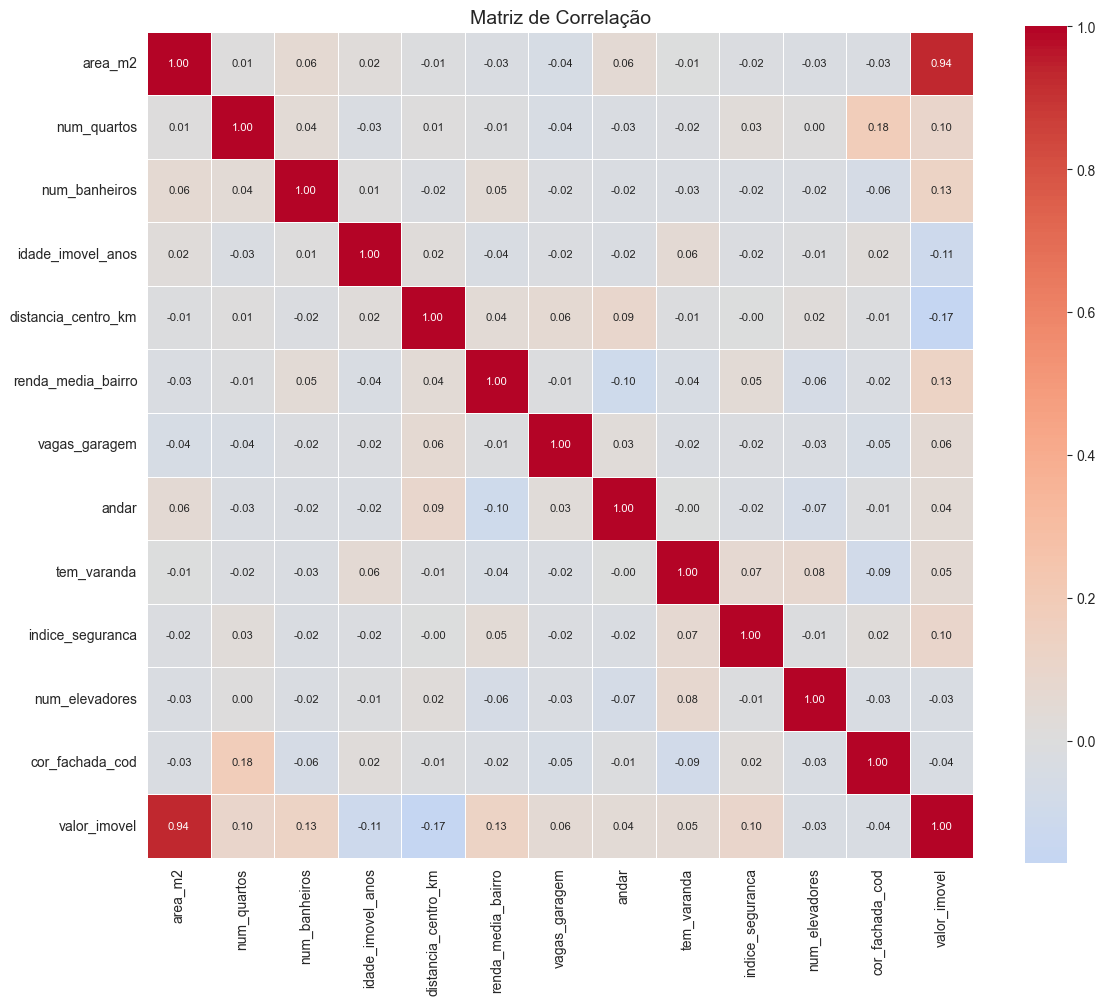

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
corr_alvo = df.corr()['valor_imovel'].drop('valor_imovel').sort_values(ascending=False)
print('Correlação com valor_imovel:\n')
for var, corr in corr_alvo.items():
    print(f'  {var:<25s} {corr:>+.4f}')

Correlação com valor_imovel:

  area_m2                   +0.9353
  renda_media_bairro        +0.1350
  num_banheiros             +0.1294
  indice_seguranca          +0.0980
  num_quartos               +0.0955
  vagas_garagem             +0.0559
  tem_varanda               +0.0516
  andar                     +0.0433
  num_elevadores            -0.0324
  cor_fachada_cod           -0.0370
  idade_imovel_anos         -0.1091
  distancia_centro_km       -0.1714


## 4. Preparação dos Dados

A padronização (StandardScaler) é **essencial** para os modelos com regularização, pois os termos de penalidade são sensíveis à escala das variáveis.

In [8]:
X = df.drop(columns='valor_imovel')
y = df['valor_imovel']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

print(f'Treino: {X_treino_scaled.shape[0]} amostras')
print(f'Teste:  {X_teste_scaled.shape[0]} amostras')

Treino: 400 amostras
Teste:  100 amostras


## 5. Modelo Base: Regressão Linear (sem regularização)

Este modelo serve como **baseline** para comparação com os modelos regularizados.

In [9]:
lr = LinearRegression()
lr.fit(X_treino_scaled, y_treino)
y_pred_lr = lr.predict(X_teste_scaled)

print('=== Regressão Linear ===')
print(f'R²:   {r2_score(y_teste, y_pred_lr):.4f}')
print(f'MAE:  R$ {mean_absolute_error(y_teste, y_pred_lr):,.2f}')
print(f'RMSE: R$ {np.sqrt(mean_squared_error(y_teste, y_pred_lr)):,.2f}')

=== Regressão Linear ===
R²:   0.9843
MAE:  R$ 24,502.47
RMSE: R$ 30,775.56


## 6. Ridge Regression (Regularização L2)

A Ridge adiciona uma penalidade proporcional à **soma dos quadrados dos coeficientes** ($\lambda \sum b_i^2$). Isso tende a **encolher** os coeficientes, mas não os zera completamente.

Usaremos `RidgeCV` para encontrar o melhor valor de $\alpha$ (intensidade da regularização) via validação cruzada.

In [10]:
alphas_ridge = np.logspace(-2, 4, 100)

ridge_cv = RidgeCV(alphas=alphas_ridge, scoring='r2', cv=5)
ridge_cv.fit(X_treino_scaled, y_treino)

print(f'Melhor alpha (Ridge): {ridge_cv.alpha_:.4f}')

y_pred_ridge = ridge_cv.predict(X_teste_scaled)

print(f'\n=== Ridge Regression ===')
print(f'R²:   {r2_score(y_teste, y_pred_ridge):.4f}')
print(f'MAE:  R$ {mean_absolute_error(y_teste, y_pred_ridge):,.2f}')
print(f'RMSE: R$ {np.sqrt(mean_squared_error(y_teste, y_pred_ridge)):,.2f}')

Melhor alpha (Ridge): 0.4329

=== Ridge Regression ===
R²:   0.9843
MAE:  R$ 24,515.94
RMSE: R$ 30,806.29


### Efeito do Alpha nos Coeficientes Ridge

Vamos visualizar como o valor de alpha afeta os coeficientes do modelo.

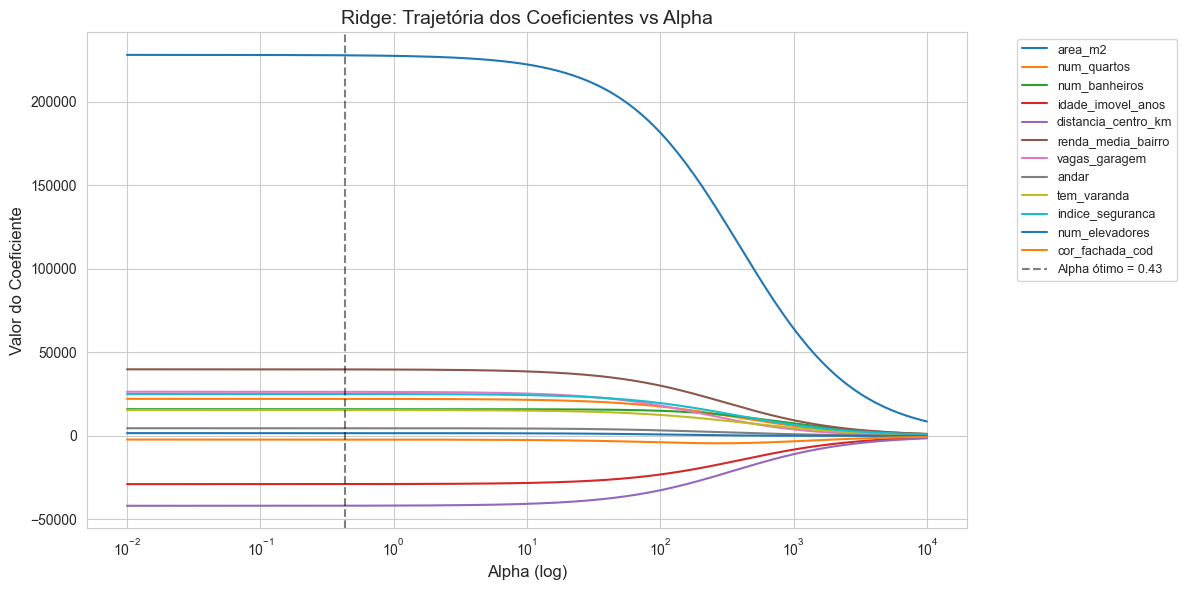

In [11]:
alphas_plot = np.logspace(-2, 4, 200)
coefs_ridge = []

for a in alphas_plot:
    ridge_temp = Ridge(alpha=a)
    ridge_temp.fit(X_treino_scaled, y_treino)
    coefs_ridge.append(ridge_temp.coef_)

coefs_ridge = np.array(coefs_ridge)

plt.figure(figsize=(12, 6))
for i, nome in enumerate(X.columns):
    plt.plot(alphas_plot, coefs_ridge[:, i], label=nome)

plt.xscale('log')
plt.xlabel('Alpha (log)', fontsize=12)
plt.ylabel('Valor do Coeficiente', fontsize=12)
plt.title('Ridge: Trajetória dos Coeficientes vs Alpha', fontsize=14)
plt.axvline(x=ridge_cv.alpha_, color='black', linestyle='--', alpha=0.5, label=f'Alpha ótimo = {ridge_cv.alpha_:.2f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Lasso Regression (Regularização L1)

A Lasso adiciona uma penalidade proporcional à **soma dos valores absolutos dos coeficientes** ($\lambda \sum |b_i|$). A principal diferença para o Ridge é que o Lasso pode **zerar coeficientes** completamente, efetivamente realizando **seleção de variáveis**.

In [12]:
lasso_cv = LassoCV(alphas=np.logspace(-2, 4, 100), cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_treino_scaled, y_treino)

print(f'Melhor alpha (Lasso): {lasso_cv.alpha_:.4f}')

y_pred_lasso = lasso_cv.predict(X_teste_scaled)

print(f'\n=== Lasso Regression ===')
print(f'R²:   {r2_score(y_teste, y_pred_lasso):.4f}')
print(f'MAE:  R$ {mean_absolute_error(y_teste, y_pred_lasso):,.2f}')
print(f'RMSE: R$ {np.sqrt(mean_squared_error(y_teste, y_pred_lasso)):,.2f}')

Melhor alpha (Lasso): 0.0100

=== Lasso Regression ===
R²:   0.9843
MAE:  R$ 24,502.48
RMSE: R$ 30,775.57


### Variáveis Selecionadas pelo Lasso

Uma das grandes vantagens do Lasso é a seleção automática de variáveis: coeficientes zerados indicam variáveis que o modelo considerou **irrelevantes**.

In [13]:
lasso_coefs = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': lasso_cv.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print('Coeficientes do Lasso:\n')
for _, row in lasso_coefs.iterrows():
    status = '✓ SELECIONADA' if abs(row['Coeficiente']) > 0.01 else '✗ eliminada'
    print(f"  {row['Variável']:<25s} {row['Coeficiente']:>+12.2f}   {status}")

n_selecionadas = (np.abs(lasso_cv.coef_) > 0.01).sum()
print(f'\nVariáveis selecionadas: {n_selecionadas} de {len(X.columns)}')

Coeficientes do Lasso:

  area_m2                     +227989.31   ✓ SELECIONADA
  distancia_centro_km          -41817.26   ✓ SELECIONADA
  renda_media_bairro           +39843.85   ✓ SELECIONADA
  idade_imovel_anos            -28855.25   ✓ SELECIONADA
  vagas_garagem                +26435.32   ✓ SELECIONADA
  indice_seguranca             +25095.92   ✓ SELECIONADA
  num_quartos                  +22182.36   ✓ SELECIONADA
  num_banheiros                +16002.69   ✓ SELECIONADA
  tem_varanda                  +15502.07   ✓ SELECIONADA
  andar                         +4604.14   ✓ SELECIONADA
  cor_fachada_cod               -2177.47   ✓ SELECIONADA
  num_elevadores                +1670.80   ✓ SELECIONADA

Variáveis selecionadas: 12 de 12


### Trajetória dos Coeficientes Lasso

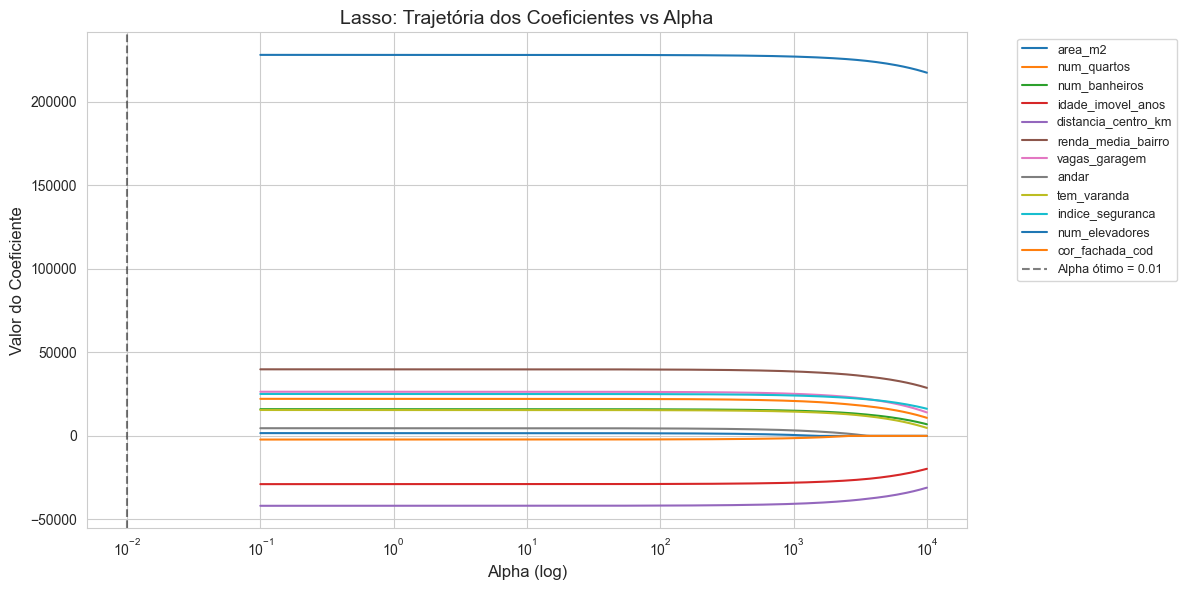

In [14]:
alphas_lasso_plot = np.logspace(-1, 4, 200)
coefs_lasso = []

for a in alphas_lasso_plot:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_treino_scaled, y_treino)
    coefs_lasso.append(lasso_temp.coef_)

coefs_lasso = np.array(coefs_lasso)

plt.figure(figsize=(12, 6))
for i, nome in enumerate(X.columns):
    plt.plot(alphas_lasso_plot, coefs_lasso[:, i], label=nome)

plt.xscale('log')
plt.xlabel('Alpha (log)', fontsize=12)
plt.ylabel('Valor do Coeficiente', fontsize=12)
plt.title('Lasso: Trajetória dos Coeficientes vs Alpha', fontsize=14)
plt.axvline(x=lasso_cv.alpha_, color='black', linestyle='--', alpha=0.5, label=f'Alpha ótimo = {lasso_cv.alpha_:.2f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Elastic Net (L1 + L2)

O Elastic Net combina as penalidades do Ridge e do Lasso. O parâmetro `l1_ratio` controla a proporção entre L1 e L2 (0 = Ridge puro, 1 = Lasso puro).

In [15]:
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    alphas=np.logspace(-2, 4, 100),
    cv=5, random_state=42, max_iter=10000
)
enet_cv.fit(X_treino_scaled, y_treino)

print(f'Melhor alpha (Elastic Net): {enet_cv.alpha_:.4f}')
print(f'Melhor l1_ratio:            {enet_cv.l1_ratio_:.2f}')

y_pred_enet = enet_cv.predict(X_teste_scaled)

print(f'\n=== Elastic Net ===')
print(f'R²:   {r2_score(y_teste, y_pred_enet):.4f}')
print(f'MAE:  R$ {mean_absolute_error(y_teste, y_pred_enet):,.2f}')
print(f'RMSE: R$ {np.sqrt(mean_squared_error(y_teste, y_pred_enet)):,.2f}')

Melhor alpha (Elastic Net): 0.0100
Melhor l1_ratio:            0.95

=== Elastic Net ===
R²:   0.9843
MAE:  R$ 24,508.06
RMSE: R$ 30,789.48


## 9. Comparação dos Modelos

In [16]:
modelos = {
    'Regressão Linear': y_pred_lr,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'Elastic Net': y_pred_enet
}

resultados = []
for nome, y_pred in modelos.items():
    resultados.append({
        'Modelo': nome,
        'R²': r2_score(y_teste, y_pred),
        'MAE (R$)': mean_absolute_error(y_teste, y_pred),
        'RMSE (R$)': np.sqrt(mean_squared_error(y_teste, y_pred))
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados['MAE (R$)'] = df_resultados['MAE (R$)'].map(lambda x: f'{x:,.2f}')
df_resultados['RMSE (R$)'] = df_resultados['RMSE (R$)'].map(lambda x: f'{x:,.2f}')
df_resultados['R²'] = df_resultados['R²'].map(lambda x: f'{x:.4f}')
df_resultados

,R²,MAE (R$),RMSE (R$)
Modelo,,,
Regressão Linear,0.9843,"24,502.47","30,775.56"
Ridge,0.9843,"24,515.94","30,806.29"
Lasso,0.9843,"24,502.48","30,775.57"
Elastic Net,0.9843,"24,508.06","30,789.48"


## 10. Validação Cruzada (5-Fold)

Para uma avaliação mais robusta, usamos validação cruzada em todo o conjunto de treino.

In [17]:
from sklearn.model_selection import cross_val_score

modelos_cv = {
    'Regressão Linear': LinearRegression(),
    'Ridge': Ridge(alpha=ridge_cv.alpha_),
    'Lasso': Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    'Elastic Net': ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000)
}

print('Validação Cruzada (5-fold) — R²:\n')
cv_results = []
for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_treino_scaled, y_treino, cv=5, scoring='r2')
    cv_results.append({'Modelo': nome, 'R² Médio': scores.mean(), 'Desvio Padrão': scores.std()})
    print(f'  {nome:<22s}  R² = {scores.mean():.4f} ± {scores.std():.4f}')

df_cv = pd.DataFrame(cv_results)
df_cv

Validação Cruzada (5-fold) — R²:

  Regressão Linear        R² = 0.9830 ± 0.0032
  Ridge                   R² = 0.9830 ± 0.0031
  Lasso                   R² = 0.9830 ± 0.0032
  Elastic Net             R² = 0.9830 ± 0.0032


,Modelo,R² Médio,Desvio Padrão
0,Regressão Linear,0.983043,0.003200
1,Ridge,0.983045,0.003143
2,Lasso,0.983043,0.003200
3,Elastic Net,0.983044,0.003179


## 11. Comparação dos Coeficientes

Vamos visualizar como cada modelo atribui pesos diferentes às variáveis.

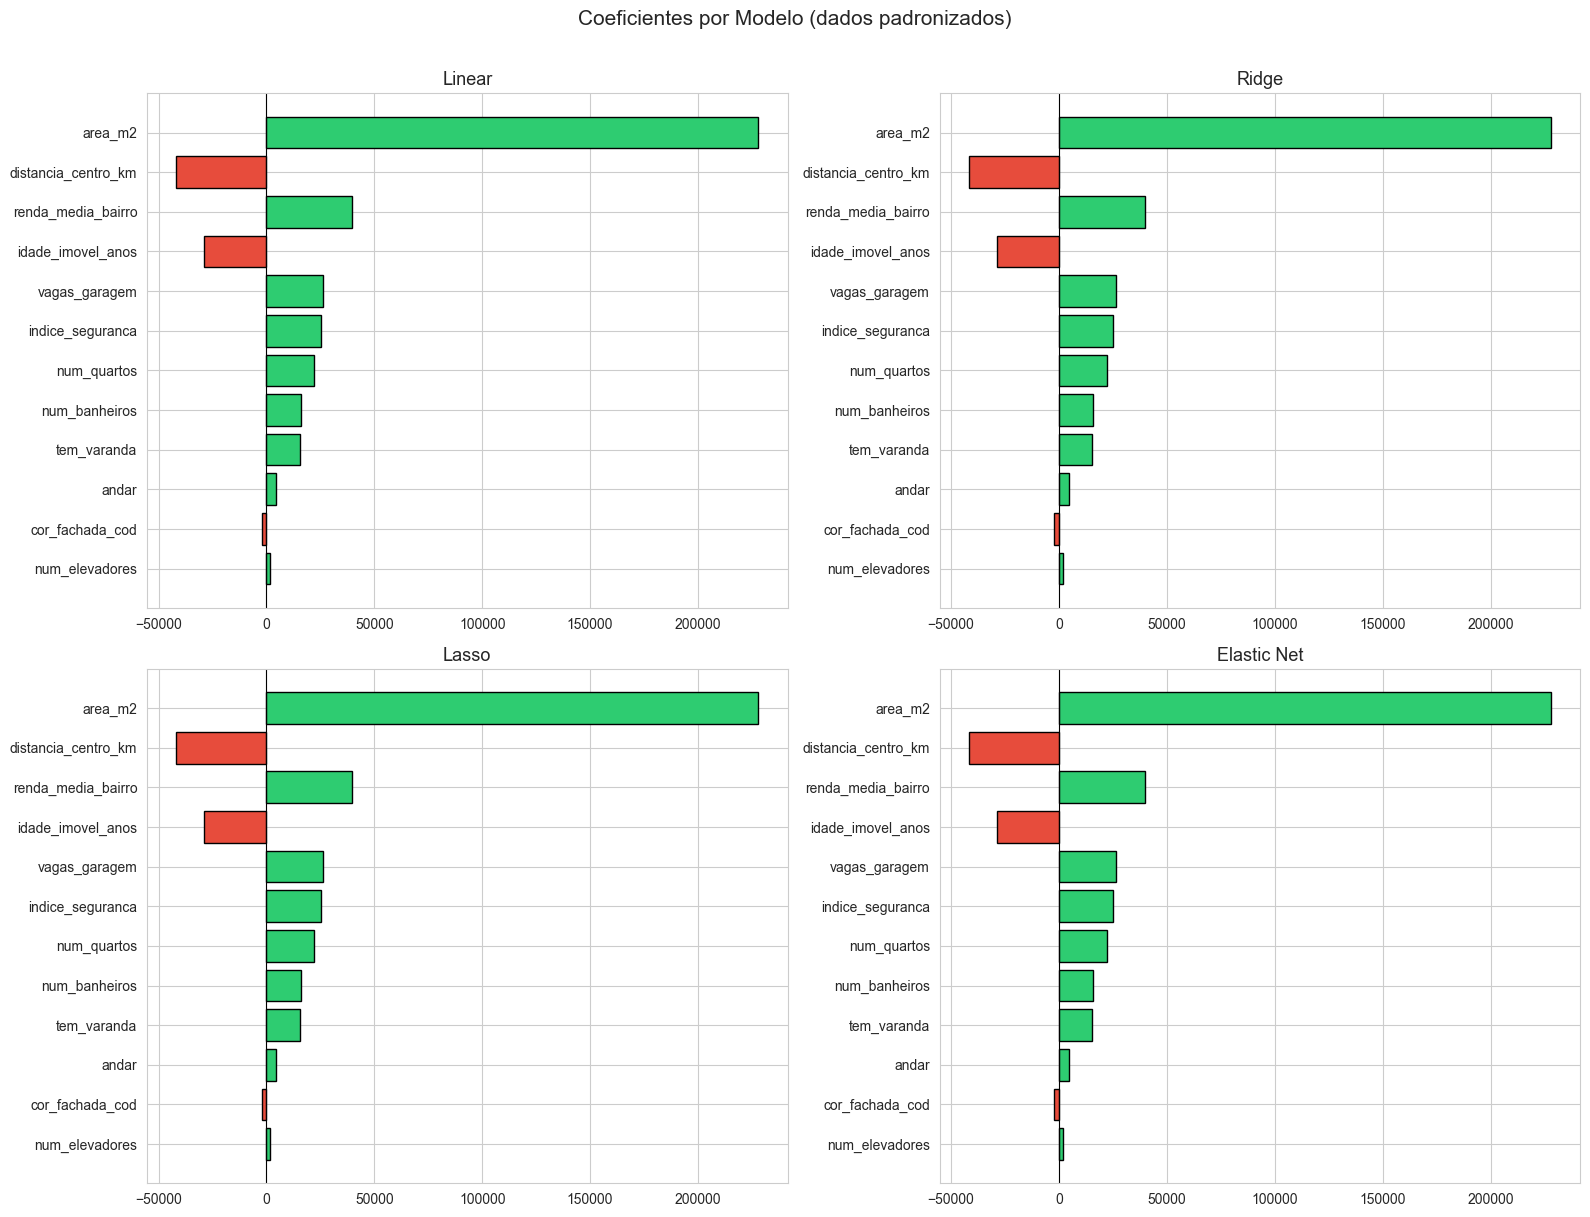

In [18]:
coefs_todos = pd.DataFrame({
    'Variável': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_,
    'Elastic Net': enet_cv.coef_
})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, modelo_nome in zip(axes.flatten(), ['Linear', 'Ridge', 'Lasso', 'Elastic Net']):
    dados = coefs_todos[['Variável', modelo_nome]].sort_values(modelo_nome, key=abs, ascending=True)
    cores = ['#e74c3c' if c < 0 else '#2ecc71' for c in dados[modelo_nome]]
    ax.barh(dados['Variável'], dados[modelo_nome], color=cores, edgecolor='black')
    ax.set_title(modelo_nome, fontsize=13)
    ax.axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Coeficientes por Modelo (dados padronizados)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Observe como o **Lasso** zera os coeficientes das variáveis irrelevantes (`cor_fachada_cod` e `num_elevadores`), enquanto o **Ridge** apenas os reduz.

## 12. Valores Reais vs Previstos (todos os modelos)

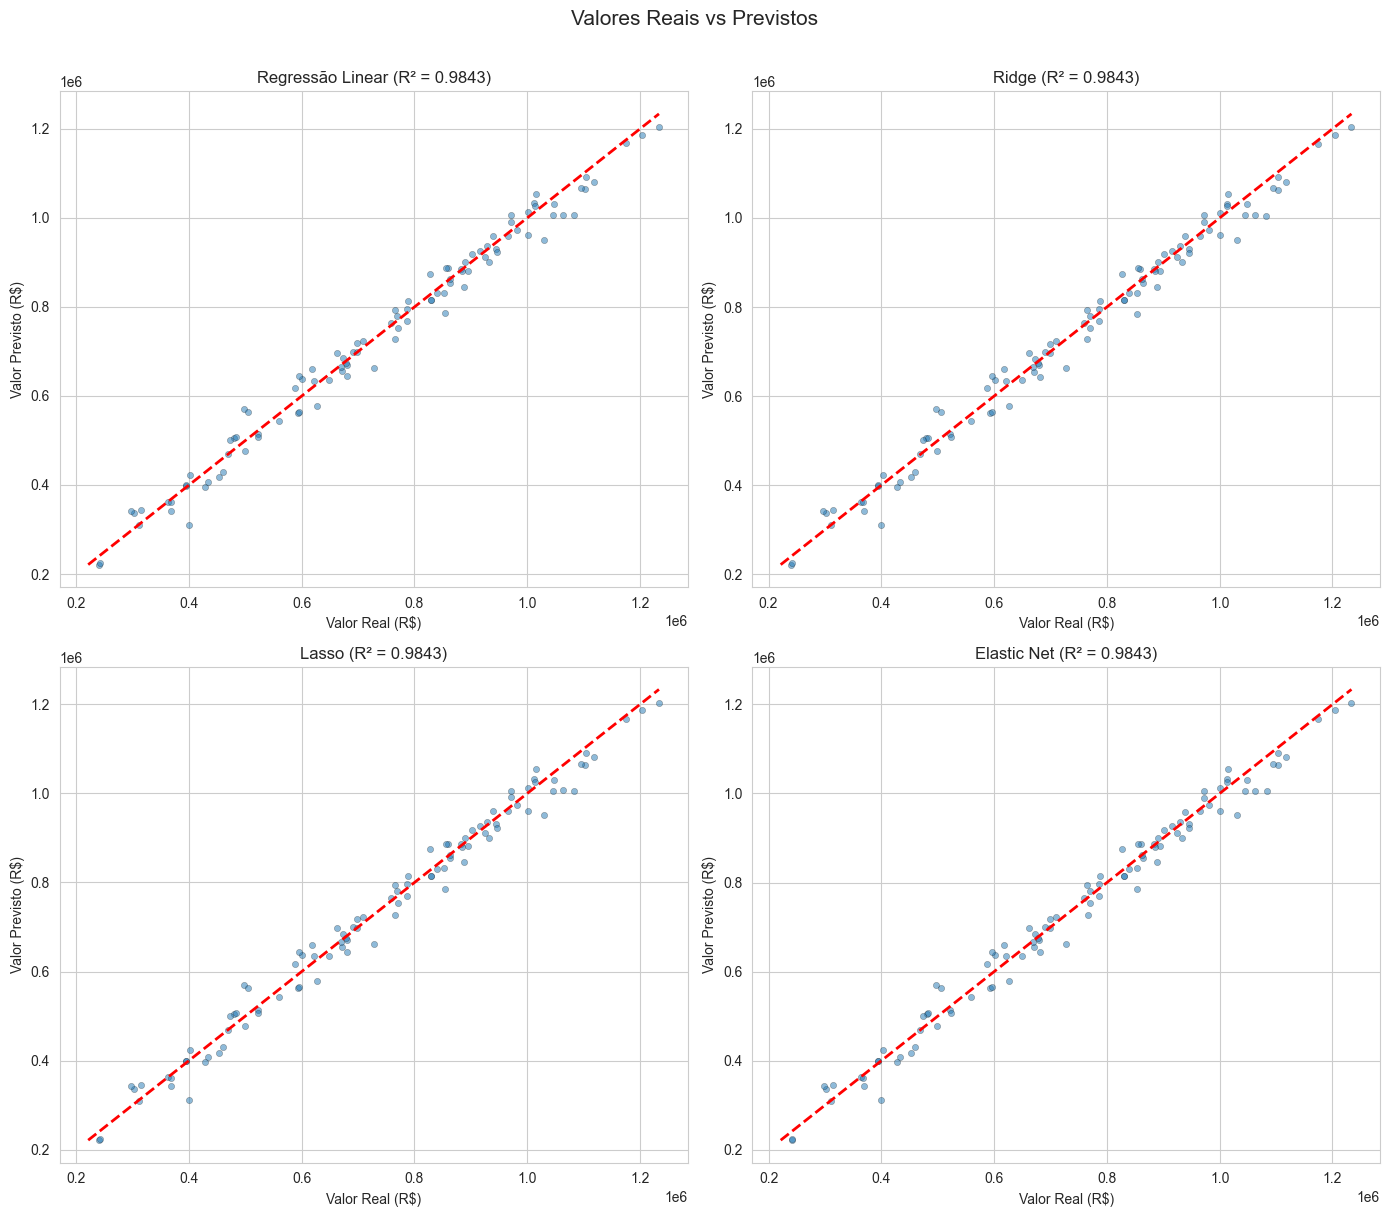

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (nome, y_pred) in zip(axes.flatten(), modelos.items()):
    ax.scatter(y_teste, y_pred, alpha=0.5, s=20, edgecolors='k', linewidths=0.3)
    lims = [min(y_teste.min(), y_pred.min()), max(y_teste.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_xlabel('Valor Real (R$)')
    ax.set_ylabel('Valor Previsto (R$)')
    r2 = r2_score(y_teste, y_pred)
    ax.set_title(f'{nome} (R² = {r2:.4f})', fontsize=12)

plt.suptitle('Valores Reais vs Previstos', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 13. Análise de Resíduos

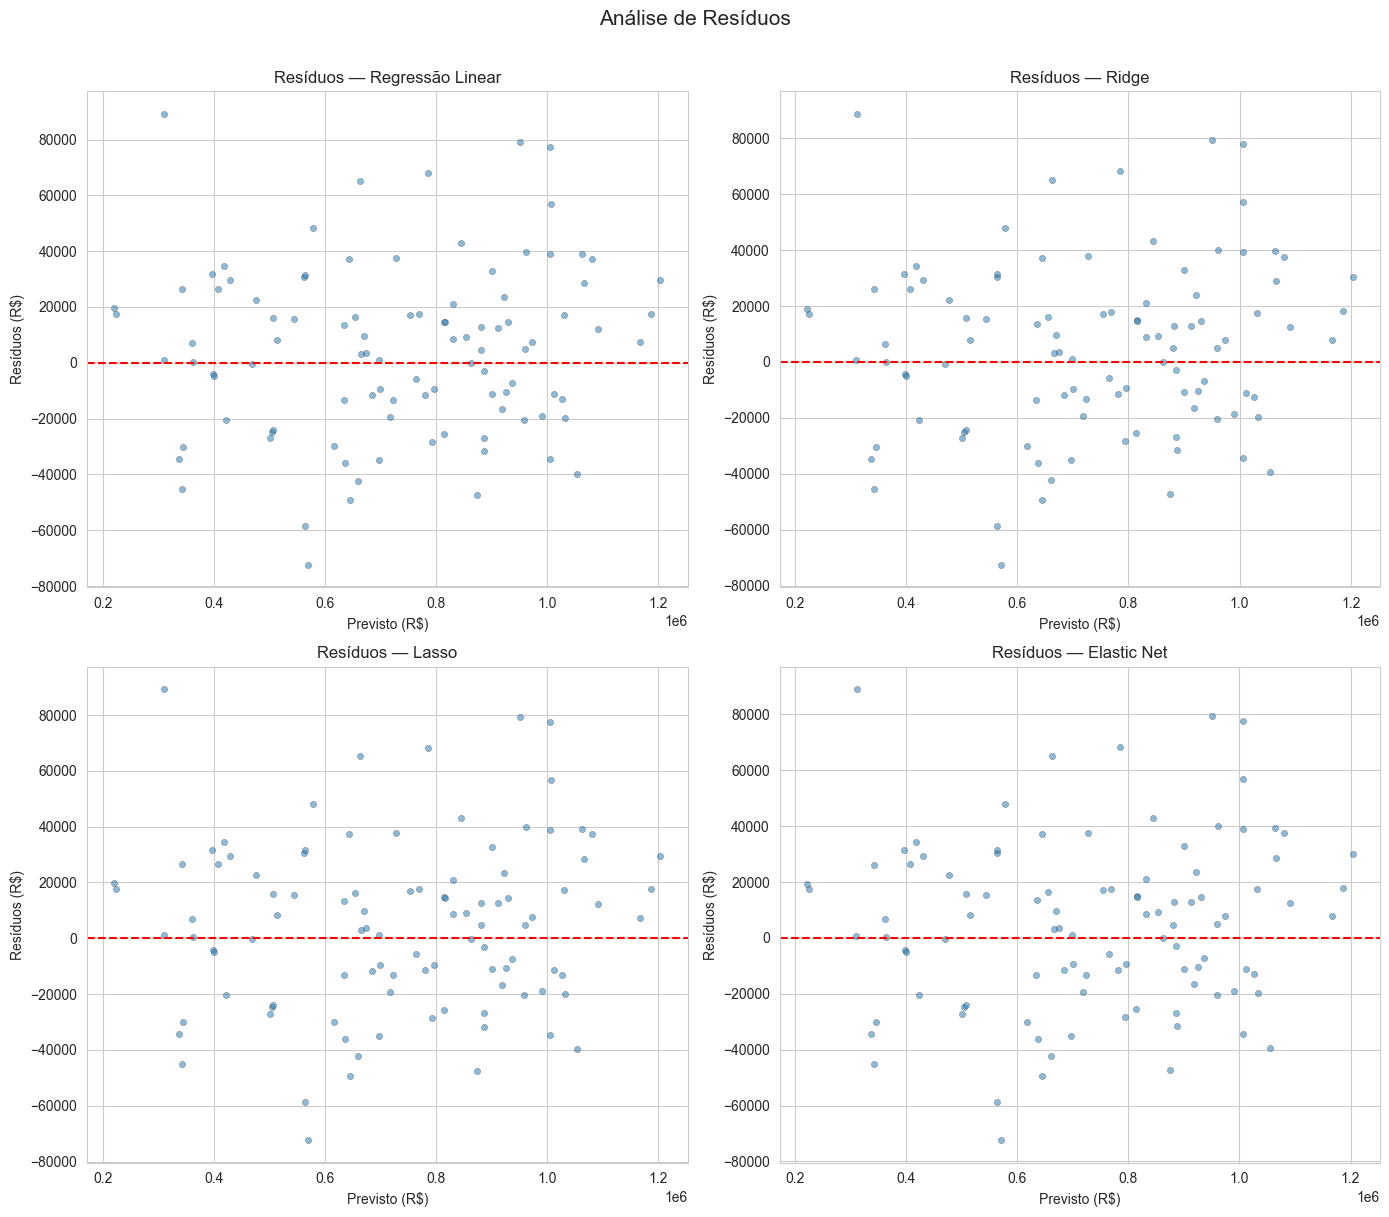

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (nome, y_pred) in zip(axes.flatten(), modelos.items()):
    residuos = y_teste - y_pred
    ax.scatter(y_pred, residuos, alpha=0.5, s=20, edgecolors='k', linewidths=0.3)
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_xlabel('Previsto (R$)')
    ax.set_ylabel('Resíduos (R$)')
    ax.set_title(f'Resíduos — {nome}', fontsize=12)

plt.suptitle('Análise de Resíduos', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()